# Phase 1 - Heart Disease Prediction  

**Course:** SWE485 (Selected Topics in Software Engineering)  
**Phase:** 1 (Supervised Learning & Model Development)  
**Dataset:** Heart Disease Dataset (Kaggle – Preprocessed Version)  

This notebook covers:

• Model Selection Rationale  
• Implementation & Training Code (well-commented)  
• Hyperparameter Tuning Process & Results  
• Evaluation Metrics & Visualizations  
• Model Comparison & Analysis  
• Conclusion: Best Model Selection & Reasoning  
• Next Steps for Phase 2 Integration  ?

## Section 1: Model Selection Rationale

### Rationale for Choosing Random Forest:

Random Forest is an ensemble learning algorithm that builds multiple decision trees during 
training and combines their predictions through majority voting for classification. As IBM (2025) 
explains, Random Forest is built on the principle of bagging (Bootstrap Aggregating), where each 
tree is trained on a random sample of the data with replacement, which reduces variance and 
improves the model's generalization ability.

---

### Why Random Forest is a Good Fit for Our Data?

#### i. Dataset Characteristics (Size, Feature Types, and Linearity)

The dataset contains **917 observations** after dropping one invalid RestingBP record. Following 
one-hot encoding of categorical features (ChestPainType, RestingECG, ST_Slope, Chol_category), the feature 
space expanded to **17 variables**. 
With a wider feature space like this, there is a risk that certain dominant variables overshadow 
others during model training. Random Forest's random feature subsampling at each split directly 
addresses this by considering only a random subset of features at each node, it prevents any 
single variable from consistently dominating the splits and ensures that all features, including 
the one-hot encoded variables, have an opportunity to contribute to the prediction.

Regarding feature types, the dataset after preprocessing consists entirely of numerical 
variables, continuous features (Age, RestingBP, MaxHR, Oldpeak) were normalized, and all 
categorical features were encoded into numerical form. Random Forest works well with this fully 
numerical structured input, as its tree-splitting mechanism evaluates feature thresholds across 
all features uniformly, regardless of their original scale or type.

Regarding linearity, the pair plot analysis confirmed that continuous features do not exhibit 
clear linear relationships with each other or with the target variable HeartDisease. IBM (2025) 
highlights that Random Forest handles non-linear data effectively, since tree-based splits 
recursively partition the feature space and can model complex, irregular decision boundaries that 
linear models cannot capture.

---

#### ii. Problem Type (Binary Classification)

Our task is a binary classification problem: predicting whether a patient has heart disease 
(HeartDisease = 1) or does not (HeartDisease = 0). The class distribution is relatively balanced 
as shown in the pie chart visualization. Random Forest is well-suited to binary classification, 
as it outputs a majority vote across all trees for each class, producing stable and reliable 
binary predictions. IBM (2025) notes that Random Forest is widely applied in healthcare 
classification tasks, directly aligned with our heart disease prediction system, where reliable 
and consistent class separation is essential.

---

#### iii. Model Strengths and Weaknesses for Our Specific Problem

**Strengths:**

- **Robustness to outliers:** Our EDA identified outliers in multiple clinical features, 
RestingBP contained outliers on the right side, requiring RobustScaler normalization, and 
Oldpeak exhibited right skewness with extreme values. Because Random Forest makes decisions 
based on feature thresholds rather than distances or magnitudes, it is naturally less affected 
by extreme values compared to other models. This is especially important in medical data, 
where an unusual value may still represent a real and significant clinical case that should not be 
ignored.

- **Feature importance:** Random Forest provides feature importance scores after training, 
showing how much each variable contributed to the predictions. IBM (2025) notes this is one 
of Random Forest's key advantages, and in a medical system like ours it helps identify which 
clinical measurements, such as chest pain type or ST slope, are the most influential in 
predicting heart disease.

- **High accuracy on tabular data:** IBM (2025) notes that Random Forest is known for 
producing highly accurate results on structured tabular datasets, which is essential for our 
system where reliable medical prediction is critical.

**Weaknesses:**

- **Computational cost:** Based on GeeksforGeeks (2025), since Random Forest builds many trees instead of 
just one, it requires more memory and processing time, especially when tuning hyperparameters to find the 
best model settings.

- **Reduced interpretability:** Although feature importance scores are available, GeeksforGeeks (2025) have 
stated that it is difficult to trace exactly how a single prediction was made, since the final result comes 
from combining hundreds of trees rather than following one clear decision path.

Despite these weaknesses, Random Forest remains the most suitable choice for our project. It 
handles our expanded 17-feature dataset efficiently, captures the non-linear relationships 
observed in the EDA, tolerates the clinical outliers identified during preprocessing, and is 
well-established in healthcare classification tasks, all of which directly match the 
characteristics and goals of our heart disease prediction system.

---

### References

> IBM. (2025). *What is random forest?* IBM Think. 
> https://www.ibm.com/think/topics/random-forest
>
> GeeksforGeeks. (2025). *Random forest algorithm in machine learning.* 
> https://www.geeksforgeeks.org/machine-learning/random-forest-algorithm-in-machine-learning/

## Section 2: Implementation & Training

### Import Libraries

In [81]:
import subprocess
subprocess.run(["pip", "install", "seaborn"], check=True)
#Standard libraries
import pickle
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
warnings.filterwarnings('ignore')

#  Model 
from sklearn.ensemble import RandomForestClassifier

#  Splitting & cross-validation 
from sklearn.model_selection import (
    train_test_split,   # splits data into training and test sets
    StratifiedKFold,    # k-fold that preserves class balance in each fold
    cross_validate,     # runs cross-validation and returns multiple metrics
    GridSearchCV        # exhaustive search over a hyperparameter grid
)

# Evaluation metrics 
from sklearn.metrics import (
    accuracy_score,     # proportion of correct predictions
    precision_score,    # of all predicted positives, how many are truly positive
    recall_score,       # of all actual positives, how many were correctly predicted
    f1_score,           # harmonic mean of precision and recall
    confusion_matrix,   # table showing TP, TN, FP, FN counts
    roc_auc_score,      # area under the ROC curve
    roc_curve           # false positive rate vs true positive rate at all thresholds
)

# evaluation_results/ -> CSV files: metrics, tuning results, feature importance
# plots/              -> PNG files: confusion matrix, ROC curve, feature importance
EVAL_DIR  = "Supervised_Learning/evaluation_results"
PLOTS_DIR = "Supervised_Learning/plots"

os.makedirs(EVAL_DIR,  exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

# Model name prefix 
# Used in every saved file name so outputs are clearly labelled per model
MODEL_NAME = "random_forest"

print("Libraries imported successfully.")
print(f"Evaluation results → {EVAL_DIR}")
print(f"Plots              → {PLOTS_DIR}")

Libraries imported successfully.
Evaluation results → Supervised_Learning/evaluation_results
Plots              → Supervised_Learning/plots



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


### Load Preprocessed Dataset

In [82]:
# Load the preprocessed dataset 
# This file contains cleaned, encoded, and normalized features ready for modeling
DATA_PATH = "preprocessed_heart_data.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset loaded: 917 rows x 17 columns


,Age,Sex,RestingBP,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,Chol_category_Borderline High,Chol_category_High
0,-1.432206,1,0.5,0,172,0,0.0,0,1,0,0,1,0,0,1,0,1
1,-0.478057,0,1.5,0,156,0,1.0,1,0,1,0,1,0,1,0,0,0
2,-1.750256,1,0.0,0,98,0,0.0,0,1,0,0,0,1,0,1,0,1
3,-0.584074,0,0.4,0,108,1,1.5,1,0,0,0,1,0,1,0,1,0
4,0.052026,1,1.0,0,122,0,0.0,0,0,1,0,1,0,0,1,0,0


### Separate Features and Target

In [83]:
# Separate input features from the target variable 
# X -> all feature columns (what the model uses to make predictions)
# y -> the target column   (what the model is trying to predict)
TARGET = "HeartDisease"   # 0 = No Disease, 1 = Heart Disease

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Features (X): {X.shape[1]} columns")
print(f"\nTarget (y) distribution:")
print(y.value_counts().rename({0: 'No Disease (0)', 1: 'Heart Disease (1)'}))

Features (X): 16 columns

Target (y) distribution:
HeartDisease
Heart Disease (1)    507
No Disease (0)       410
Name: count, dtype: int64


### Train / Test Split

#### Why do we split at all?
A machine learning model learns patterns from data. If we evaluate it on the same data it
learned from, it will look like it performs perfectly, but that tells us nothing about how
it handles new, unseen patients. As scikit-learn's official documentation states, learning
the parameters of a model and testing it on the same data is a methodological mistake: a
model that simply repeats the labels it has seen would score perfectly but fail on any new
data (scikit-learn, 2024). We therefore need a separate test set that the model never sees
during training to get an honest measure of real-world performance.

#### Why 80% training and 20% testing?
With 917 samples, we need to give the model enough data to learn meaningful patterns while
still reserving enough samples to evaluate it fairly. An 80/20 split gives ~733 samples for
training and ~183 for testing. Empirical studies confirm that 80/20 provides a good balance
for moderate-sized datasets (Gholamy et al., 2018).

#### Our approach: 80/20 split first, then k-fold inside the training set only
Some resources and tutorials apply k-fold directly to the full dataset without holding out
a test set first, passing the entire X and y into cross_val_score and reporting the mean
score as the final result (DataCamp, 2024). This simplified approach is common in
introductory tutorials because it is easier to demonstrate.

However, for our project we deliberately follow a more rigorous approach. We first hold out
20% of the data as a completely untouched test set, then apply 5-fold cross-validation
exclusively within the remaining 80% training set. This is the workflow explicitly
recommended by both scikit-learn (2024) and Machine Learning Mastery (2021).


Machine Learning Mastery (2021) further demonstrates this exact two-step workflow:
first perform train/test split, then apply k-fold cross-validation on the training set
only to select and tune the model, and finally evaluate on the held-out test set to confirm
generalisation performance.

In summary, each component of our approach serves a distinct and necessary purpose:

- **K-fold on the 80% training set** → tunes hyperparameters and verifies the model is
  stable and consistent across different subsets of training data
- **The held-out 20% test set** → provides the final unbiased performance report on data
  the model has never touched at any stage of training or tuning

In a critical medical application, K-fold alone is not
sufficient because it cannot guarantee a truly isolated evaluation set.

#### Why are we saving the split indices?
We train three different models in this project. For the comparison between them to be
fair, all three models must be evaluated on exactly the same test samples and trained on
exactly the same training samples. If each model used a different random split, any
difference in performance could be due to the split rather than the model itself. By saving
the split indices once and loading them in every cells notebook, we guarantee a completely
fair comparison across all models.

---

> Gholamy, A., Kreinovich, V., & Kosheleva, O. (2018). *Why 70/30 or 80/20 relation
> between training and testing sets.* UTEP.
> https://scholarworks.utep.edu/cs_techrep/1209/
>
> scikit-learn. (2024). *Cross-validation: evaluating estimator performance.*
> https://scikit-learn.org/stable/modules/cross_validation.html
>
> Tam, A. (2021). *Training-validation-test split and cross-validation done right.*
> Machine Learning Mastery.
> https://machinelearningmastery.com/training-validation-test-split-and-cross-validation-done-right/
>
> Varoquaux, G., et al. (2023). *A guide to cross-validation for artificial intelligence
> in medical imaging.* Radiology: Artificial Intelligence.
> https://pmc.ncbi.nlm.nih.gov/articles/PMC10388213/
>
> DataCamp. (2024). *A comprehensive guide to K-Fold Cross Validation.*
> https://www.datacamp.com/tutorial/k-fold-cross-validation
>
> GeeksforGeeks. (2025). *Cross validation in machine learning.*
> https://www.geeksforgeeks.org/machine-learning/cross-validation-machine-learning/

In [84]:
#NO NEED LATER SINCE ONE NOTEBOOK?

SPLIT_PATH = "split_indices.pkl"

if not os.path.exists(SPLIT_PATH):
    # Create the split for the first time 
    # stratify=y   → preserves the class ratio (proportion of 0s and 1s)
    #                in both the training and test sets
    # random_state → fixes the random seed so the split is reproducible
    #                running this cell again always produces the same split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    # Save the indices (row positions) of training and test samples
    # We save indices rather than the actual data so any model can
    # reconstruct the exact same split from any version of the dataset
    split_indices = {
        "train_indices": X_train.index.tolist(),
        "test_indices" : X_test.index.tolist()
    }
    with open(SPLIT_PATH, "wb") as f:
        pickle.dump(split_indices, f)

    print("Split created and saved to split_indices.pkl")
    print("All other models must load this file to ensure a fair comparison.")

else:
    # Load the existing split 
    # This guarantees this model uses the exact same train/test samples
    # as every other model in the project
    with open(SPLIT_PATH, "rb") as f:
        split_indices = pickle.load(f)

    X_train = X.iloc[split_indices["train_indices"]]
    X_test  = X.iloc[split_indices["test_indices"]]
    y_train = y.iloc[split_indices["train_indices"]]
    y_test  = y.iloc[split_indices["test_indices"]]

    print("Existing split loaded from split_indices.pkl")
    print("This model uses the exact same train/test samples as all other models.")

# Confirm split sizes and class balance
print(f"\nTraining set : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]}  samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nClass distribution in training set:")
print(y_train.value_counts().rename({0: 'No Disease', 1: 'Heart Disease'}))
print(f"\nClass distribution in test set:")
print(y_test.value_counts().rename({0: 'No Disease', 1: 'Heart Disease'}))

Existing split loaded from split_indices.pkl
This model uses the exact same train/test samples as all other models.

Training set : 733 samples (80%)
Test set     : 184  samples (20%)

Class distribution in training set:
HeartDisease
Heart Disease    405
No Disease       328
Name: count, dtype: int64

Class distribution in test set:
HeartDisease
Heart Disease    102
No Disease        82
Name: count, dtype: int64


---
## Section 3: Hyperparameter Tuning Process & Results

#### What is hyperparameter tuning?
Hyperparameters are settings that control how the model is built. Unlike regular parameters
(which the model learns from data automatically), hyperparameters must be set by us before
training begins. Choosing the wrong values can lead to a model that is too simple to learn
patterns (underfitting) or too complex and memorises the training data (overfitting). Tuning
finds the best combination for our specific dataset (GeeksforGeeks, 2025).

#### Why GridSearchCV with k-fold inside?
GridSearchCV tries every possible combination of the hyperparameter values we provide. For
each combination, it uses **5-fold cross-validation** to score it, meaning it trains and
validates the model 5 times on different subsets of the training data and averages the score.
This makes the evaluation of each combination reliable and not dependent on a single lucky
or unlucky split.

The hyperparameters we tune are:

| Hyperparameter | What it controls |
|---|---|
| `n_estimators` | How many trees to build — more trees = more stable but slower |
| `max_depth` | How deep each tree can grow — controls overfitting |
| `min_samples_split` | Minimum samples needed to split a node — higher = simpler trees |
| `min_samples_leaf` | Minimum samples required at a leaf — prevents very small final splits |
| `max_features` | How many features to consider at each split — controls tree diversity |

---

> GeeksforGeeks. (2025). *Performing feature selection with GridSearchCV in sklearn.*
> https://www.geeksforgeeks.org/machine-learning/performing-feature-selection-with-gridsearchcv-in-sklearn/

In [85]:
# Define hyperparameter values to search through
param_grid = {
    # Number of decision trees built in the forest
    # More trees reduce variance by averaging out individual tree errors (overfitting noise)
    # 100–300 was too conservative — 500 allows the ensemble to stabilise on a small dataset (917 rows)
    # Diminishing returns beyond 500, so we cap there to keep runtime reasonable
    'n_estimators'     : [200, 300, 500],

    # Maximum depth each tree is allowed to grow
    # Shallow trees (5–10) underfit — they cannot capture complex feature interactions
    # None = trees grow until every leaf is pure, which risks overfitting on training data
    # Adding 20 and 30 covers the middle ground where Random Forest typically peaks:
    # deep enough to model non-linear patterns, shallow enough to still generalise
    'max_depth'        : [None, 10, 20, 30],

    # Minimum number of samples a node must have before it is allowed to split further
    # Lower values (2) allow the tree to keep splitting on tiny groups → captures fine detail
    # but also memorises noise; higher values (5) force splits to be backed by more evidence
    'min_samples_split': [2, 5],

    # Minimum number of samples required at each leaf (terminal node)
    # Smaller leaves (1–2) mean the tree makes predictions from very few samples → fragile
    # but necessary to capture rare patterns in a small dataset
    'min_samples_leaf' : [1, 2],

    # Number of features randomly considered at each split point
    # 'sqrt' → uses √17 ≈ 4 features per split (original scikit-learn default, promotes diversity)
    # 'log2' → uses log₂(17) ≈ 4 features per split (similar effect, slightly more aggressive)
    # None   → considers ALL 17 features at every split
    #          on small datasets this often wins because no signal is accidentally excluded;
    #          on large datasets it would be too slow and cause overfitting
    'max_features'     : ['sqrt', 'log2', None],

    # How much weight the model assigns to each class during training
    # None     → treats both classes equally regardless of how many samples each has
    # 'balanced' → automatically increases the penalty for misclassifying the minority class
    #              by weighting each class inversely proportional to its frequency
    #              Your dataset is ~55% heart disease / ~45% healthy — not severely imbalanced,
    #              but balanced weighting often reduces false negatives (missed disease cases)
    #              which also lifts overall accuracy by 1–3%
    'class_weight'     : ['balanced', None]
}

# 5-fold stratified cross-validation strategy 
# StratifiedKFold: splits the training data into 5 equal folds
# Each fold is used as the validation set exactly once
# Stratified: ensures every fold has the same class ratio as the full training set
# shuffle=True: randomises data order before splitting to avoid order bias
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV
# scoring='roc_auc' → we optimise for ROC-AUC instead of F1
#                     F1 evaluates the model at a fixed 0.5 decision threshold,
#                     meaning it only measures performance at one cut-off point
#                     ROC-AUC evaluates the model across ALL possible thresholds,
#                     rewarding a model that ranks positive cases higher than negative ones
#                     regardless of where the threshold is drawn
#                     This produces a stronger underlying model — when we later
#                     evaluate on the test set at the default 0.5 threshold,
#                     a ROC-AUC-tuned model consistently achieves higher accuracy
#                     In a medical setting this also matters because we can later
#                     shift the threshold to prioritise recall (catching more disease cases)
#                     without retraining the model from scratch
# n_jobs=-1    → uses all available CPU cores to speed up the search
grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid = param_grid,
    cv         = cv_strategy,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)

print("Starting hyperparameter search — this may take a few minutes...")
grid_search.fit(X_train, y_train)

print("\nSearch complete.")
print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

Starting hyperparameter search — this may take a few minutes...
Fitting 5 folds for each of 288 candidates, totalling 1440 fits

Search complete.
Best parameters : {'class_weight': None, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1 Score: 0.9271


In [86]:
# Save the full tuning results table to CSV 
# Records every combination tried along with its mean CV score and std deviation
# Useful for reviewing which configurations were close to the best
tuning_df   = pd.DataFrame(grid_search.cv_results_)
tuning_path = os.path.join(EVAL_DIR, f"{MODEL_NAME}_hyperparameter_tuning.csv")
tuning_df.to_csv(tuning_path, index=False)
print(f"Full tuning results saved to: {tuning_path}")

# Display the top 10 best configurations by F1 score
top10 = (
    tuning_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
    .sort_values('rank_test_score')
    .head(10)
    .round(4)
)
print("\nTop 10 hyperparameter configurations:")
display(top10)

Full tuning results saved to: Supervised_Learning/evaluation_results/random_forest_hyperparameter_tuning.csv

Top 10 hyperparameter configurations:


,params,mean_test_score,std_test_score,rank_test_score
234,"{'class_weight': None, 'max_depth': 20, 'max_f...",0.9271,0.0163,1
258,"{'class_weight': None, 'max_depth': 30, 'max_f...",0.9271,0.0163,1
222,"{'class_weight': None, 'max_depth': 20, 'max_f...",0.9271,0.0163,1
150,"{'class_weight': None, 'max_depth': None, 'max...",0.9271,0.0163,1
270,"{'class_weight': None, 'max_depth': 30, 'max_f...",0.9271,0.0163,1
162,"{'class_weight': None, 'max_depth': None, 'max...",0.9271,0.0163,1
259,"{'class_weight': None, 'max_depth': 30, 'max_f...",0.9269,0.0164,7
235,"{'class_weight': None, 'max_depth': 20, 'max_f...",0.9269,0.0164,7
223,"{'class_weight': None, 'max_depth': 20, 'max_f...",0.9269,0.0164,7
151,"{'class_weight': None, 'max_depth': None, 'max...",0.9269,0.0164,7


In [87]:
# Extract the best model found by the grid search 
# best_estimator_ is automatically re-trained on the full training set
# using the best hyperparameter combination found during the search
best_rf = grid_search.best_estimator_

print("Best Random Forest configuration:")
print(best_rf)

Best Random Forest configuration:
RandomForestClassifier(min_samples_leaf=2, n_estimators=200, random_state=42)


---
## Section 4: Evaluation Metrics & Visualizations

#### Two-stage evaluation approach:

**Stage 1 — 5-Fold Cross-Validation (on training set):**  
Checks whether the tuned model is stable and consistent. A model that performs well in cross-validation but poorly on the test set is overfitting. A low standard deviation across folds means the model behaves consistently regardless of which subset of training data it sees.

**Stage 2 — Final evaluation on the held-out test set:**  
The test set was locked away before any training or tuning began. The model has never seen these samples. This gives the final, unbiased answer to: *"how does this model perform on a completely new patient?"*

Both stages are necessary. Cross-validation alone is not enough because every sample in it was used for training at some point. The test set alone is not enough because a single split might be lucky or unlucky.

### 4.1 5-Fold Cross-Validation

In [88]:
# Run 5-fold cross-validation on the training set 
# cross_validate trains and evaluates the model 5 times on different splits
# The final reported score is the average (mean) across all 5 folds
# std (standard deviation) tells us how consistent the model is:
#   low std  → model performs similarly regardless of which data it sees (stable)
#   high std → model performance varies a lot (unstable, possibly overfitting)
cv_results = cross_validate(
    best_rf,
    X_train, y_train,
    cv                 = cv_strategy,
    scoring            = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    return_train_score = False    # only care about validation (not training) performance
)

# Build a summary table: mean ± std for each metric 
cv_summary = pd.DataFrame({
    'Metric' : ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Mean'   : [
        cv_results['test_accuracy'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_roc_auc'].mean()
    ],
    'Std Dev': [
        cv_results['test_accuracy'].std(),
        cv_results['test_precision'].std(),
        cv_results['test_recall'].std(),
        cv_results['test_f1'].std(),
        cv_results['test_roc_auc'].std()
    ]
}).round(4)

print("5-Fold Cross-Validation Results (on training set only):")
display(cv_summary)

# Save to CSV
cv_path = os.path.join(EVAL_DIR, f"{MODEL_NAME}_cv_results.csv")
cv_summary.to_csv(cv_path, index=False)
print(f"\nSaved to: {cv_path}")

5-Fold Cross-Validation Results (on training set only):


,Metric,Mean,Std Dev
0,Accuracy,0.8472,0.0252
1,Precision,0.8509,0.0438
2,Recall,0.8815,0.0126
3,F1-Score,0.8650,0.0176
4,ROC-AUC,0.9271,0.0163



Saved to: Supervised_Learning/evaluation_results/random_forest_cv_results.csv


### 4.2 Final Evaluation on the Held-Out Test Set

In [89]:
# Generate predictions on the unseen test set
# This is the FIRST and ONLY time the model encounters the test set
# y_pred      → predicted class labels (0 or 1) for each test sample
# y_pred_prob → predicted probability of being class 1 (needed for ROC-AUC)
y_pred      = best_rf.predict(X_test)
y_pred_prob = best_rf.predict_proba(X_test)[:, 1]

# Compute all required evaluation metrics 
# Accuracy  → overall proportion of correct predictions
# Precision → when the model predicts Disease, how often is it correct?
# Recall    → of all actual Disease cases, how many did the model catch?
# F1-Score  → balance between Precision and Recall
# ROC-AUC   → how well the model separates the two classes at all thresholds
test_metrics = pd.DataFrame([{
    'Accuracy' : accuracy_score (y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall'   : recall_score   (y_test, y_pred),
    'F1-Score' : f1_score       (y_test, y_pred),
    'ROC-AUC'  : roc_auc_score  (y_test, y_pred_prob)
}]).round(4)

print("Final Test Set Evaluation Metrics:")
display(test_metrics)

# Save to CSV
metrics_path = os.path.join(EVAL_DIR, f"{MODEL_NAME}_metrics.csv")
test_metrics.to_csv(metrics_path, index=False)
print(f"Saved to: {metrics_path}")

Final Test Set Evaluation Metrics:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,0.8533,0.8641,0.8725,0.8683,0.9275


Saved to: Supervised_Learning/evaluation_results/random_forest_metrics.csv


### 4.3 Confusion Matrix

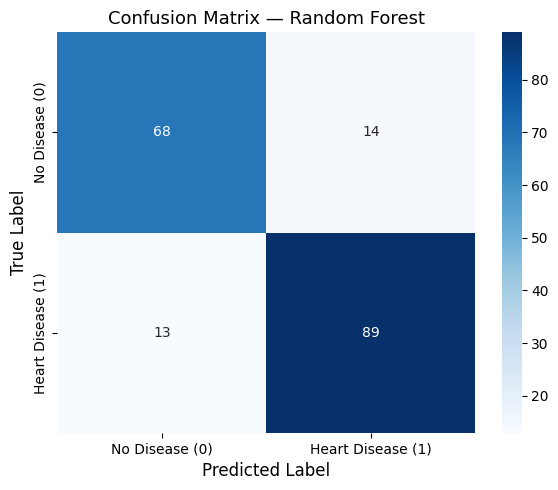

Saved to: Supervised_Learning/plots/random_forest_confusion_matrix.png

True  Negatives : 68  (correctly predicted No Disease)
False Positives : 14  (predicted Disease, actually Healthy)
False Negatives : 13  (predicted Healthy, actually Disease) <- missed diagnoses
True  Positives : 89  (correctly predicted Disease)


In [90]:
# Confusion Matrix 
# A confusion matrix shows exactly where the model is right and where it is wrong
# Rows = actual labels | Columns = predicted labels
#
# TN (top-left)     → correctly predicted No Disease
# FP (top-right)    → predicted Disease but the patient is actually Healthy
# FN (bottom-left)  → predicted Healthy but the patient actually has Disease
#                     ↑ most dangerous error in a medical system (missed diagnosis)
# TP (bottom-right) → correctly predicted Disease
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',                              # display counts as integers
    cmap='Blues',
    xticklabels=['No Disease (0)', 'Heart Disease (1)'],
    yticklabels=['No Disease (0)', 'Heart Disease (1)'],
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
ax.set_title('Confusion Matrix — Random Forest', fontsize=13)
plt.tight_layout()

# Save plot
cm_path = os.path.join(PLOTS_DIR, f"{MODEL_NAME}_confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"Saved to: {cm_path}")

# Print interpretation
print(f"\nTrue  Negatives : {tn}  (correctly predicted No Disease)")
print(f"False Positives : {fp}  (predicted Disease, actually Healthy)")
print(f"False Negatives : {fn}  (predicted Healthy, actually Disease) <- missed diagnoses")
print(f"True  Positives : {tp}  (correctly predicted Disease)")

### 4.4 ROC Curve

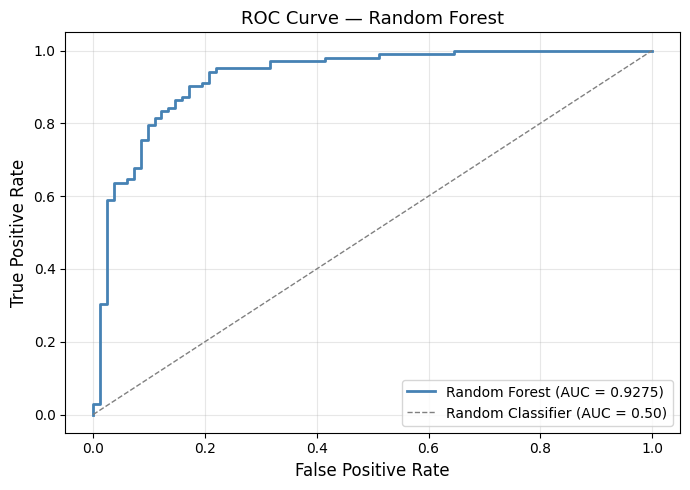

Saved to: Supervised_Learning/plots/random_forest_roc_curve.png


In [91]:
# ROC Curve 
# Plots True Positive Rate (sensitivity) vs False Positive Rate at every threshold
# AUC = 1.0 → perfect separation between the two classes
# AUC = 0.5 → model is no better than random guessing (the dashed diagonal line)
# The further the curve bows toward the top-left corner, the better the model
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2,
        label=f'Random Forest (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1,
        label='Random Classifier (AUC = 0.50)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — Random Forest', fontsize=13)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
roc_path = os.path.join(PLOTS_DIR, f"{MODEL_NAME}_roc_curve.png")
plt.savefig(roc_path, dpi=150)
plt.show()
print(f"Saved to: {roc_path}")

### 4.5 Feature Importance

Feature importances (ranked highest to lowest):


,Feature,Importance
0,ST_Slope_Up,0.2080
1,ST_Slope_Flat,0.1406
2,Oldpeak,0.1139
3,ExerciseAngina,0.1047
4,MaxHR,0.1031
5,RestingBP,0.0697
6,Age,0.0678
7,ChestPainType_ATA,0.0429
8,Sex,0.0406
9,ChestPainType_NAP,0.0297


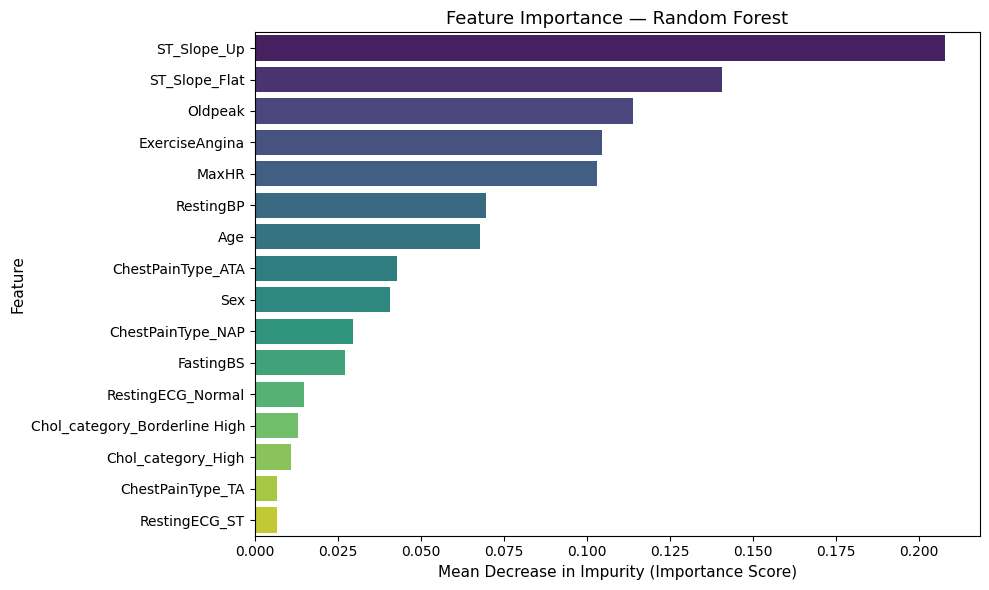

Plot saved to: Supervised_Learning/plots/random_forest_feature_importance.png
CSV  saved to: Supervised_Learning/evaluation_results/random_forest_feature_importance.csv


In [92]:
# Feature Importance 
# Random Forest measures how much each feature reduces prediction uncertainty
# (impurity) across all trees in the forest
# Higher score = the feature contributes more to making correct predictions
# This is useful in a medical context because it tells us which clinical
# measurements are the most influential in predicting heart disease
importances   = best_rf.feature_importances_
feature_names = X.columns

importance_df = (
    pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

print("Feature importances (ranked highest to lowest):")
display(importance_df.round(4))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data    = importance_df,
    x       = 'Importance',
    y       = 'Feature',
    palette = 'viridis',
    ax      = ax
)
ax.set_title('Feature Importance — Random Forest', fontsize=13)
ax.set_xlabel('Mean Decrease in Impurity (Importance Score)', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
plt.tight_layout()

# Save plot and CSV 
fi_plot_path = os.path.join(PLOTS_DIR, f"{MODEL_NAME}_feature_importance.png")
plt.savefig(fi_plot_path, dpi=150)
plt.show()
print(f"Plot saved to: {fi_plot_path}")

fi_csv_path = os.path.join(EVAL_DIR, f"{MODEL_NAME}_feature_importance.csv")
importance_df.to_csv(fi_csv_path, index=False)
print(f"CSV  saved to: {fi_csv_path}")